# RMSNorm vs LayerNorm: 直观理解指南

本笔记本将帮助你直观地理解 **RMSNorm** 和 **LayerNorm** 的区别，包括：
1. 数学原理
2. 代码实现
3. 可视化对比
4. 为什么 LLaMA 等现代模型选择 RMSNorm

In [1]:
!pip install --upgrade numpy matplotlib

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子保证可重复性
torch.manual_seed(42)
np.random.seed(42)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://mirrors.ustc.edu.cn/pypi/simple


## 1. 数学公式对比

### LayerNorm 公式

给定输入向量 $\mathbf{x} \in \mathbb{R}^d$，LayerNorm 的计算如下：

$$\text{LayerNorm}(\mathbf{x}) = \gamma \odot \frac{\mathbf{x} - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

其中：
- $\mu = \frac{1}{d} \sum_{i=1}^{d} x_i$ （均值）
- $\sigma^2 = \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2$ （方差）
- $\gamma, \beta \in \mathbb{R}^d$ 是可学习参数
- $\epsilon$ 是小常数，防止除零

### RMSNorm 公式

$$\text{RMSNorm}(\mathbf{x}) = \gamma \odot \frac{\mathbf{x}}{\text{RMS}(\mathbf{x})}$$

其中：
- $\text{RMS}(\mathbf{x}) = \sqrt{\frac{1}{d} \sum_{i=1}^{d} x_i^2 + \epsilon}$ （均方根）
- $\gamma \in \mathbb{R}^d$ 是可学习参数
- **注意：没有 $\beta$ 偏置项，也没有减去均值！**

## 2. 核心区别可视化

让我们用一张图来理解两者的区别：

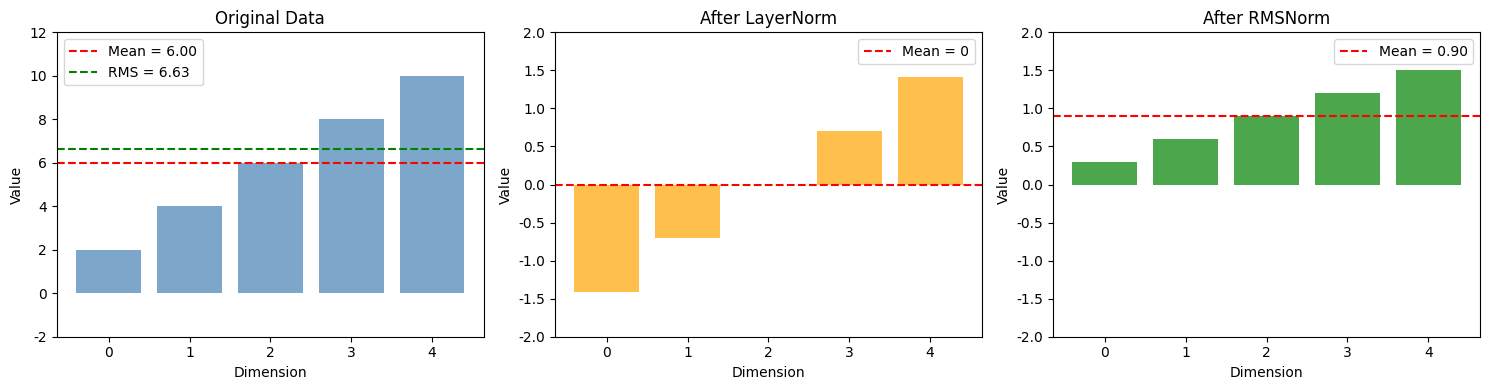

原始数据: [ 2  4  6  8 10]
LayerNorm 后 (均值中心化 + 标准化): [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
RMSNorm 后 (仅缩放，无中心化): [0.30151134 0.60302269 0.90453403 1.20604538 1.50755672]


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 创建示例数据
x = np.array([2, 4, 6, 8, 10])
d = len(x)

# LayerNorm 计算步骤
mu = x.mean()
sigma = x.std()
x_layernorm = (x - mu) / (sigma + 1e-8)

# RMSNorm 计算步骤
rms = np.sqrt(np.mean(x**2) + 1e-8)
x_rmsnorm = x / rms

# 绘制原始数据
axes[0].bar(range(d), x, color='steelblue', alpha=0.7)
axes[0].axhline(y=mu, color='red', linestyle='--', label=f'Mean = {mu:.2f}')
axes[0].axhline(y=rms, color='green', linestyle='--', label=f'RMS = {rms:.2f}')
axes[0].set_title('Original Data', fontsize=12)
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].set_ylim(-2, 12)

# 绘制 LayerNorm 结果
axes[1].bar(range(d), x_layernorm, color='orange', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', label='Mean = 0')
axes[1].set_title('After LayerNorm', fontsize=12)
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].set_ylim(-2, 2)

# 绘制 RMSNorm 结果
axes[2].bar(range(d), x_rmsnorm, color='green', alpha=0.7)
axes[2].axhline(y=x_rmsnorm.mean(), color='red', linestyle='--', 
                label=f'Mean = {x_rmsnorm.mean():.2f}')
axes[2].set_title('After RMSNorm', fontsize=12)
axes[2].set_xlabel('Dimension')
axes[2].set_ylabel('Value')
axes[2].legend()
axes[2].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

print(f"原始数据: {x}")
print(f"LayerNorm 后 (均值中心化 + 标准化): {x_layernorm}")
print(f"RMSNorm 后 (仅缩放，无中心化): {x_rmsnorm}")

### 关键洞察 🎯

| 特性 | LayerNorm | RMSNorm |
|------|-----------|----------|
| **减去均值** | ✅ 是（中心化） | ❌ 否 |
| **缩放方式** | 除以标准差 | 除以 RMS |
| **偏置参数 β** | ✅ 有 | ❌ 无 |
| **输出均值** | 0（经过中心化） | 保留原始比例关系 |
| **计算量** | 较多 | 较少 |

## 3. 代码实现

In [3]:
class LayerNorm(nn.Module):
    """标准的 Layer Normalization"""
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        # 可学习参数
        self.gamma = nn.Parameter(torch.ones(d_model))   # 缩放
        self.beta = nn.Parameter(torch.zeros(d_model))   # 偏移
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (..., d_model)
        # 步骤 1: 计算均值 (沿最后一个维度)
        mean = x.mean(dim=-1, keepdim=True)
        
        # 步骤 2: 计算方差
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        
        # 步骤 3: 归一化 (减均值，除标准差)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        
        # 步骤 4: 应用可学习参数
        return self.gamma * x_norm + self.beta


class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization"""
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        # 只有缩放参数，没有偏移！
        self.gamma = nn.Parameter(torch.ones(d_model))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (..., d_model)
        # 步骤 1: 计算 RMS (均方根)
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        
        # 步骤 2: 归一化 (只除以 RMS，不减均值！)
        x_norm = x / rms
        
        # 步骤 3: 应用缩放参数
        return self.gamma * x_norm


print("✅ LayerNorm 和 RMSNorm 类定义完成")

✅ LayerNorm 和 RMSNorm 类定义完成


## 4. 实际效果对比

In [4]:
# 创建测试数据
batch_size, seq_len, d_model = 2, 4, 8
x = torch.randn(batch_size, seq_len, d_model)

# 初始化两种归一化
ln = LayerNorm(d_model)
rmsn = RMSNorm(d_model)

# 前向传播
y_ln = ln(x)
y_rmsn = rmsn(x)

print("输入 x 的形状:", x.shape)
print("\n" + "="*50)
print("LayerNorm 输出统计:")
print(f"  均值 (沿 d_model): {y_ln.mean(dim=-1).mean():.6f}")
print(f"  标准差 (沿 d_model): {y_ln.std(dim=-1).mean():.6f}")

print("\nRMSNorm 输出统计:")
print(f"  均值 (沿 d_model): {y_rmsn.mean(dim=-1).mean():.6f}")
print(f"  RMS (沿 d_model): {torch.sqrt((y_rmsn**2).mean(dim=-1)).mean():.6f}")
print("="*50)

输入 x 的形状: torch.Size([2, 4, 8])

LayerNorm 输出统计:
  均值 (沿 d_model): 0.000000
  标准差 (沿 d_model): 1.069038

RMSNorm 输出统计:
  均值 (沿 d_model): 0.035593
  RMS (沿 d_model): 0.999995


## 5. 分布可视化对比

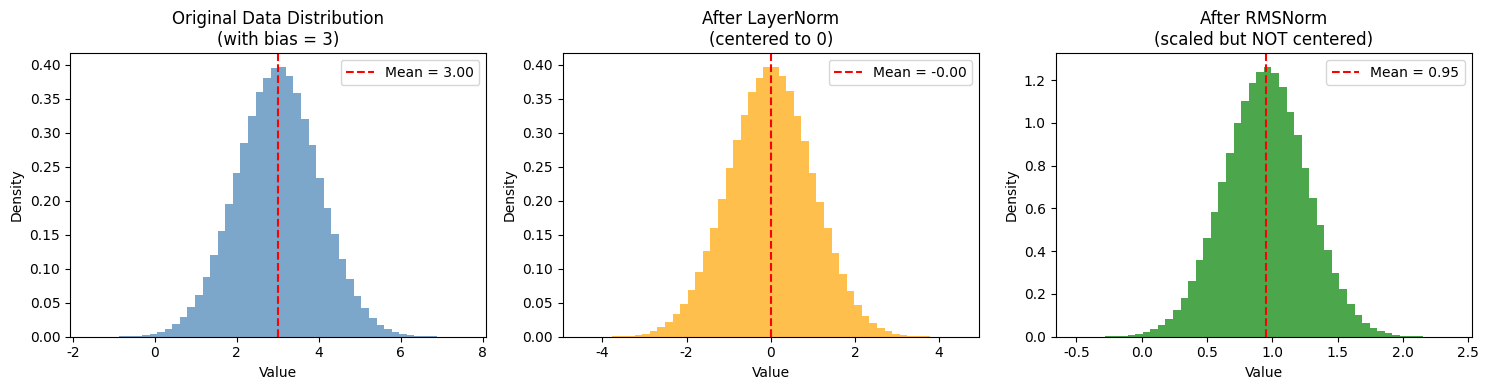


🔍 观察：
- LayerNorm: 输出中心在 0 附近（减去了均值）
- RMSNorm: 输出中心不在 0（保留了原始数据的偏移特性）


In [5]:
# 生成更多数据来观察分布
torch.manual_seed(42)
x_test = torch.randn(1000, 512)  # 1000 个样本，每个 512 维

# 使用有偏移的数据来更好地展示差异
x_biased = x_test + 3  # 添加偏移，使均值不为 0

ln_test = LayerNorm(512)
rmsn_test = RMSNorm(512)

with torch.no_grad():
    y_ln_test = ln_test(x_biased)
    y_rmsn_test = rmsn_test(x_biased)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 原始数据分布
axes[0].hist(x_biased.flatten().numpy(), bins=50, alpha=0.7, color='steelblue', density=True)
axes[0].axvline(x=x_biased.mean().item(), color='red', linestyle='--', 
                label=f'Mean = {x_biased.mean().item():.2f}')
axes[0].set_title('Original Data Distribution\n(with bias = 3)', fontsize=12)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()

# LayerNorm 后的分布
axes[1].hist(y_ln_test.flatten().numpy(), bins=50, alpha=0.7, color='orange', density=True)
axes[1].axvline(x=y_ln_test.mean().item(), color='red', linestyle='--',
                label=f'Mean = {y_ln_test.mean().item():.2f}')
axes[1].set_title('After LayerNorm\n(centered to 0)', fontsize=12)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()

# RMSNorm 后的分布
axes[2].hist(y_rmsn_test.flatten().numpy(), bins=50, alpha=0.7, color='green', density=True)
axes[2].axvline(x=y_rmsn_test.mean().item(), color='red', linestyle='--',
                label=f'Mean = {y_rmsn_test.mean().item():.2f}')
axes[2].set_title('After RMSNorm\n(scaled but NOT centered)', fontsize=12)
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n🔍 观察：")
print("- LayerNorm: 输出中心在 0 附近（减去了均值）")
print("- RMSNorm: 输出中心不在 0（保留了原始数据的偏移特性）")

## 6. 计算效率对比 ⚡

In [6]:
import time

# 大规模测试
batch_size, seq_len, d_model = 32, 2048, 4096
x_large = torch.randn(batch_size, seq_len, d_model)

ln_large = LayerNorm(d_model)
rmsn_large = RMSNorm(d_model)

# 预热
for _ in range(10):
    _ = ln_large(x_large)
    _ = rmsn_large(x_large)

# LayerNorm 计时
n_iterations = 100
start = time.time()
for _ in range(n_iterations):
    _ = ln_large(x_large)
ln_time = (time.time() - start) / n_iterations * 1000

# RMSNorm 计时
start = time.time()
for _ in range(n_iterations):
    _ = rmsn_large(x_large)
rmsn_time = (time.time() - start) / n_iterations * 1000

print(f"输入形状: ({batch_size}, {seq_len}, {d_model})")
print(f"\nLayerNorm 平均耗时: {ln_time:.2f} ms")
print(f"RMSNorm 平均耗时:   {rmsn_time:.2f} ms")
print(f"\n🚀 RMSNorm 比 LayerNorm 快约 {((ln_time - rmsn_time) / ln_time * 100):.1f}%")

输入形状: (32, 2048, 4096)

LayerNorm 平均耗时: 1382.75 ms
RMSNorm 平均耗时:   778.13 ms

🚀 RMSNorm 比 LayerNorm 快约 43.7%


## 7. 参数数量对比

In [7]:
d_model = 4096  # 类似 LLaMA-7B

ln_params = sum(p.numel() for p in LayerNorm(d_model).parameters())
rmsn_params = sum(p.numel() for p in RMSNorm(d_model).parameters())

print(f"对于 d_model = {d_model}:")
print(f"  LayerNorm 参数量: {ln_params:,} (gamma + beta)")
print(f"  RMSNorm 参数量:   {rmsn_params:,} (只有 gamma)")
print(f"\n参数减少: {(ln_params - rmsn_params) / ln_params * 100:.0f}%")

# 如果模型有很多归一化层
n_layers = 32  # 类似 LLaMA-7B
norms_per_layer = 2  # attention 和 FFN 各一个

total_ln_params = ln_params * n_layers * norms_per_layer
total_rmsn_params = rmsn_params * n_layers * norms_per_layer

print(f"\n对于 {n_layers} 层模型 (每层 {norms_per_layer} 个归一化层):")
print(f"  LayerNorm 总参数: {total_ln_params:,}")
print(f"  RMSNorm 总参数:   {total_rmsn_params:,}")
print(f"  节省参数: {total_ln_params - total_rmsn_params:,}")

对于 d_model = 4096:
  LayerNorm 参数量: 8,192 (gamma + beta)
  RMSNorm 参数量:   4,096 (只有 gamma)

参数减少: 50%

对于 32 层模型 (每层 2 个归一化层):
  LayerNorm 总参数: 524,288
  RMSNorm 总参数:   262,144
  节省参数: 262,144


## 8. 为什么 LLaMA 等现代模型选择 RMSNorm？

### 实验证据

RMSNorm 的论文 ["Root Mean Square Layer Normalization"](https://arxiv.org/abs/1910.07467) 发现：

1. **去中心化步骤不是必须的**：研究表明，LayerNorm 的成功主要来自于**缩放**，而不是**中心化**

2. **相似的模型性能**：在多个任务上，RMSNorm 达到了与 LayerNorm 相当的性能

3. **更快的训练速度**：省去均值计算可以节省 10-30% 的归一化层计算时间

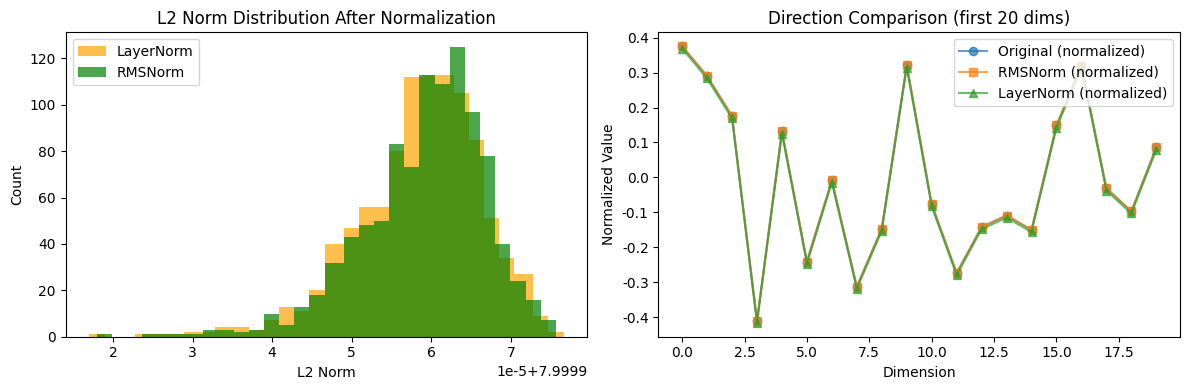


🔑 关键洞察:
1. 两种方法都能有效控制激活值的范数
2. RMSNorm 更好地保持了原始数据的'方向'
3. 对于深度网络，稳定范数比中心化更重要


In [8]:
# 让我们直观理解为什么去中心化可能不那么重要

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 生成一些模拟的激活值
torch.manual_seed(42)
x = torch.randn(1000, 64)

# 模拟训练过程中，网络会学习调整参数
ln = LayerNorm(64)
rmsn = RMSNorm(64)

with torch.no_grad():
    y_ln = ln(x)
    y_rmsn = rmsn(x)

# 计算每个样本的 L2 范数 (这是模型训练中更关键的)
ln_norms = torch.norm(y_ln, dim=-1)
rmsn_norms = torch.norm(y_rmsn, dim=-1)

axes[0].hist(ln_norms.numpy(), bins=30, alpha=0.7, label='LayerNorm', color='orange')
axes[0].hist(rmsn_norms.numpy(), bins=30, alpha=0.7, label='RMSNorm', color='green')
axes[0].set_title('L2 Norm Distribution After Normalization', fontsize=12)
axes[0].set_xlabel('L2 Norm')
axes[0].set_ylabel('Count')
axes[0].legend()

# 显示缩放效果（方向保持）
# 取两个样本看方向是否保持
sample_idx = 0
x_sample = x[sample_idx].numpy()
y_ln_sample = y_ln[sample_idx].numpy()
y_rmsn_sample = y_rmsn[sample_idx].numpy()

# 可视化前 20 个维度
dims = range(20)
axes[1].plot(dims, x_sample[:20] / np.linalg.norm(x_sample[:20]), 
             'o-', label='Original (normalized)', alpha=0.7)
axes[1].plot(dims, y_rmsn_sample[:20] / np.linalg.norm(y_rmsn_sample[:20]), 
             's-', label='RMSNorm (normalized)', alpha=0.7)
axes[1].plot(dims, y_ln_sample[:20] / np.linalg.norm(y_ln_sample[:20]), 
             '^-', label='LayerNorm (normalized)', alpha=0.7)
axes[1].set_title('Direction Comparison (first 20 dims)', fontsize=12)
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Normalized Value')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n🔑 关键洞察:")
print("1. 两种方法都能有效控制激活值的范数")
print("2. RMSNorm 更好地保持了原始数据的'方向'")
print("3. 对于深度网络，稳定范数比中心化更重要")

## 9. 与 PyTorch 官方实现对比验证

In [9]:
# 验证我们的 LayerNorm 实现与 PyTorch 官方实现一致
d_model = 64
x = torch.randn(4, 8, d_model)

# 我们的实现
our_ln = LayerNorm(d_model)

# PyTorch 官方实现
pytorch_ln = nn.LayerNorm(d_model)

# 同步参数
with torch.no_grad():
    our_ln.gamma.copy_(pytorch_ln.weight)
    our_ln.beta.copy_(pytorch_ln.bias)

# 对比输出
y_ours = our_ln(x)
y_pytorch = pytorch_ln(x)

max_diff = (y_ours - y_pytorch).abs().max().item()
print(f"我们的 LayerNorm vs PyTorch LayerNorm")
print(f"最大差异: {max_diff:.2e}")
print(f"✅ 实现正确!" if max_diff < 1e-5 else "❌ 实现有误")

我们的 LayerNorm vs PyTorch LayerNorm
最大差异: 4.77e-07
✅ 实现正确!


## 10. 总结

### LayerNorm vs RMSNorm 对比表

| 特性 | LayerNorm | RMSNorm |
|------|-----------|----------|
| **公式** | $(x - \mu) / \sigma$ | $x / \text{RMS}(x)$ |
| **中心化** | ✅ 减去均值 | ❌ 不减 |
| **参数** | $\gamma$ (scale) + $\beta$ (bias) | 只有 $\gamma$ (scale) |
| **计算量** | 更多（需计算均值和方差） | 更少 |
| **性能** | 基准 | 相当或略优 |
| **使用模型** | BERT, GPT-2 | LLaMA, GPT-3+ |

### 何时选择哪个？

- **RMSNorm**：现代大语言模型首选，计算效率高
- **LayerNorm**：传统选择，如果需要严格的零均值输出